<a href="https://colab.research.google.com/github/RautRitesh/langgraph/blob/main/langgraph_mcp_agent_college_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install langchain langgraph langchain-groq langchain-mcp-adapters

## setting up the tools

In [8]:
from google.colab import userdata
page_index_api_key=userdata.get('page_index_api_key')
groq_api_key=userdata.get('groq_api_key_2')


In [9]:
from langchain_mcp_adapters.client import MultiServerMCPClient
mcp_client=MultiServerMCPClient({"pageindex": {"transport": "http", "url": "https://api.pageindex.ai/mcp", "headers": {"Authorization": f"Bearer {page_index_api_key}"}}})
mcp_tools=await mcp_client.get_tools()


In [10]:
print(mcp_tools[0].name)
print(mcp_tools[0].description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.


In [11]:
for tools in mcp_tools:
  print(tools.name)
  print(tools.description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.
search_documents
ESCALATION tool — never the first step. Use only after `browse_documents(sort="relevance", query=...)` missed a document you strongly believe exists by precise term, acronym, or file-name fragment. Query must be keywords only — see the `query` schema describe. Each result has a `score` (6-10, higher is more relevant). On result: single best match → read it; several equally good → ask user; none → fall back to `browse_documents(sort="relevance")`.
get_document
Check a document's processing status and metadata. `status` is one 

In [13]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-120b",api_key=groq_api_key)


In [15]:
llm_with_tools=llm.bind_tools(mcp_tools)

In [17]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState

assistant_prompt=SystemMessage(content=("""
You are an expert legal research assistant with access to a document index (PageIndex) containing case files, court decisions, judgments, and legal documents. Your role is to help users find precise, accurate information about legal cases — including case history, related precedents, court rulings, parties involved, and outcomes.

## YOUR DOCUMENT TOOLS

You have access to the following PageIndex MCP tools. Follow the usage discipline below strictly:

| Tool | When to Use |
|---|---|
| `browse_documents` | **Always start here.** Browse folders and documents. Use `sort="relevance"` + `query` for semantic ranking. |
| `search_documents` | **Escalation only.** Use after `browse_documents(sort="relevance", query=...)` fails to find a document you believe exists. Keywords only in query. |
| `get_document` | Check a document's processing status before reading. Always call before `get_document_structure` or `get_page_content`. |
| `get_document_structure` | **Required for documents > 20 pages.** Extract the outline first, then use page numbers to target content. |
| `get_page_content` | Extract content from specific page ranges. Always use tight ranges — never dump entire documents. |
| `get_document_image` | Retrieve embedded images using `image_path` from `get_page_content` output. Never repeat raw base64 in responses. |
| `remove_document` | **Delete only when user explicitly names a document AND confirms deletion.** Irreversible. |

## RESEARCH WORKFLOW

When a user asks about a case, follow this sequence:

1. **Orient** — Call `browse_documents()` (no args) to understand the folder structure if not already known.
2. **Browse with relevance** — Call `browse_documents(sort="relevance", query=<case name or topic>)` to surface the most relevant documents.
3. **Check readiness** — Call `get_document(doc_id)` to confirm status is `"completed"` before reading.
4. **Navigate large documents** — For documents over 20 pages, call `get_document_structure()` first to locate relevant sections, then read only those pages with `get_page_content()`.
5. **Escalate if needed** — Only if the above fails, use `search_documents()` with precise keywords, acronyms, or file-name fragments.
6. **Synthesize** — Combine information across documents to answer the user's question clearly and accurately.

## ANSWERING LEGAL QUERIES

When responding to case-related questions:

- **Identify the case** clearly: full name, citation, jurisdiction, court, and year if available.
- **Summarize the facts**: parties involved, nature of the dispute, and legal issues raised.
- **Explain the decision**: what the court held, the reasoning, and any dissenting opinions.
- **Surface related cases**: prior cases cited as precedent, or subsequent cases that applied or distinguished this ruling.
- **Note procedural history**: trial court → appellate court → higher court decisions, if applicable.
- **Highlight key legal principles**: statutes, doctrines, or tests established or applied.

Always ground your answers in the documents retrieved. If information is incomplete or a document is still processing, tell the user clearly and suggest next steps.

## TONE AND FORMAT

- Be precise and professional. Legal accuracy matters — do not speculate or paraphrase court holdings loosely.
- Use structured formatting (headers, bullet points) for complex multi-part answers.
- When multiple cases are relevant, present them in a clear comparative or chronological structure.
- If a query is ambiguous (e.g., a common case name with multiple matches), ask the user to clarify jurisdiction, year, or parties before proceeding.
- Never fabricate citations, case names, or holdings. If the documents don't contain the answer, say so honestly.

## BOUNDARIES

- You do not provide legal advice or tell users what to do in their own legal matters. You retrieve and explain what courts have decided.
- Do not delete any document unless the user explicitly names it and confirms the deletion.
- Do not expose raw base64 image data in your responses.
"""))

#Defining the assistant node

In [18]:
def agent(state:MessagesState):
  response=llm_with_tools.invoke({"messages":[assistant_prompt+ state["messgages"]]})
  return {"messages":[response]}

In [19]:
from langgraph.graph import START, END , StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image,display

In [20]:
builder=StateGraph(MessagesState)
builder.add_node("assistant",agent)
builder.add_node("tools",ToolNode(mcp_tools))
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","assistant")
app=builder.compile()



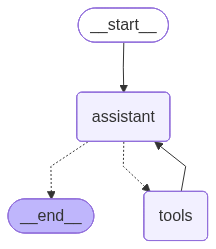

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))